In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "nalisha/tesla-ea-deliveries-and-production-data20152025"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Path to dataset files: /kaggle/input/tesla-ea-deliveries-and-production-data20152025


In [4]:
import os

os.listdir(path)

['tesla_deliveries_dataset_2015_2025.csv']

In [5]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "tesla_deliveries_dataset_2015_2025.csv"))

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [8]:
df.shape

(2640, 12)

In [9]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

##missing values


In [10]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


##**EDA**

>

##duplicate records


In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


##correlation heatmap

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

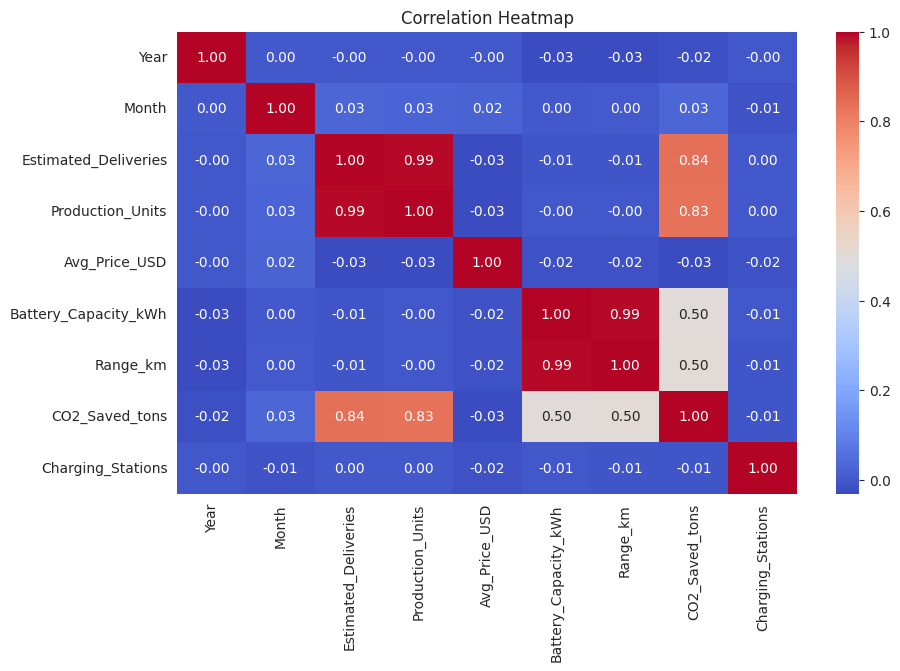

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

##distribution of deliveries

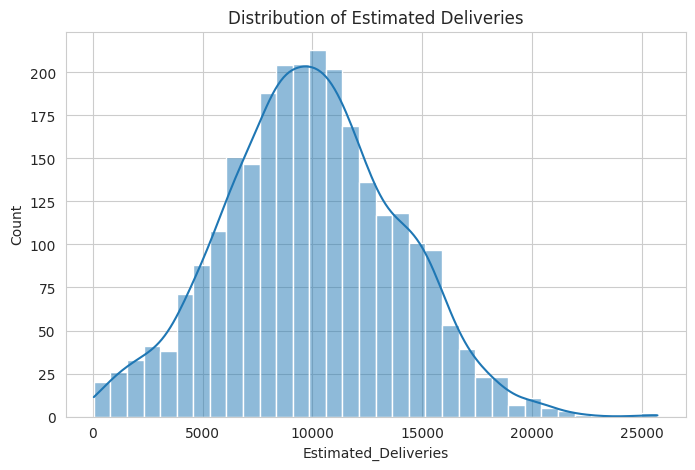

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Estimated_Deliveries"], kde=True)

plt.title("Distribution of Estimated Deliveries")
plt.show()

##production vs deliveries

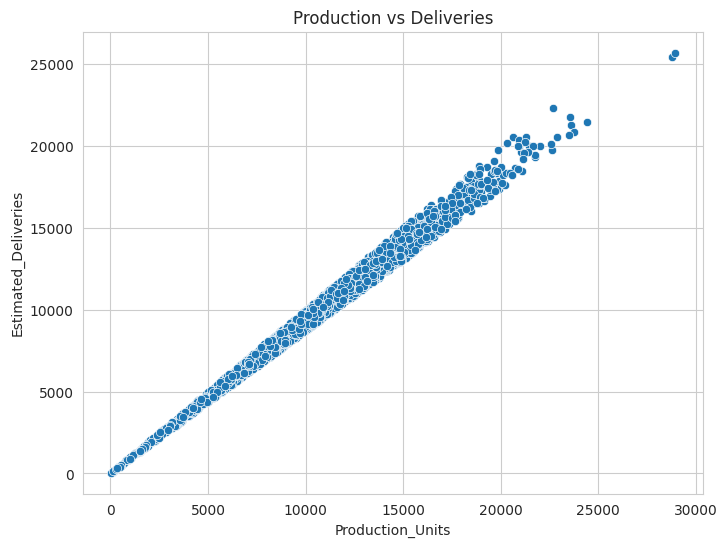

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production vs Deliveries")
plt.show()

avg price by model

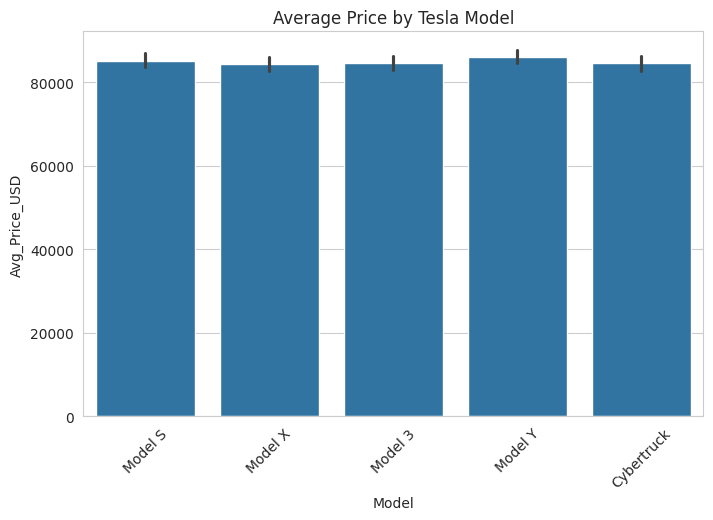

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Model",
    y="Avg_Price_USD"
)

plt.title("Average Price by Tesla Model")
plt.xticks(rotation=45)

plt.show()

##deliveries by region

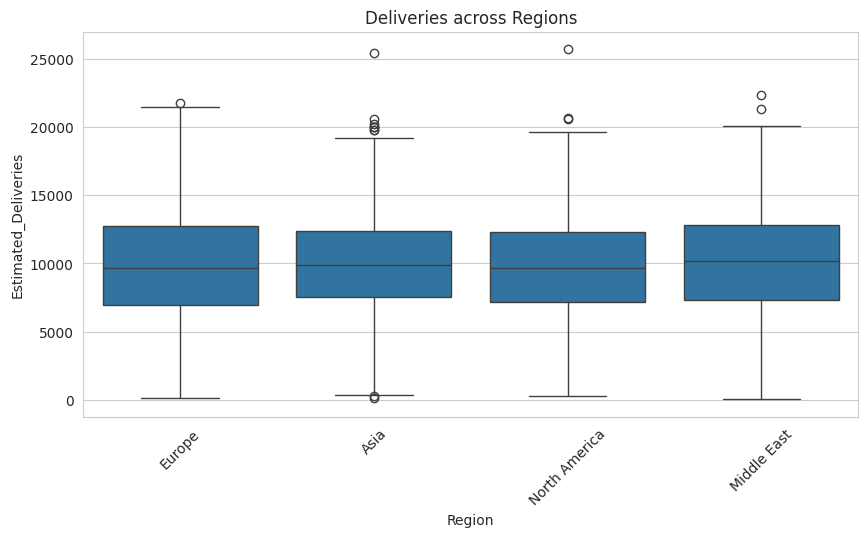

In [18]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)

plt.title("Deliveries across Regions")

plt.show()

##yearly trend

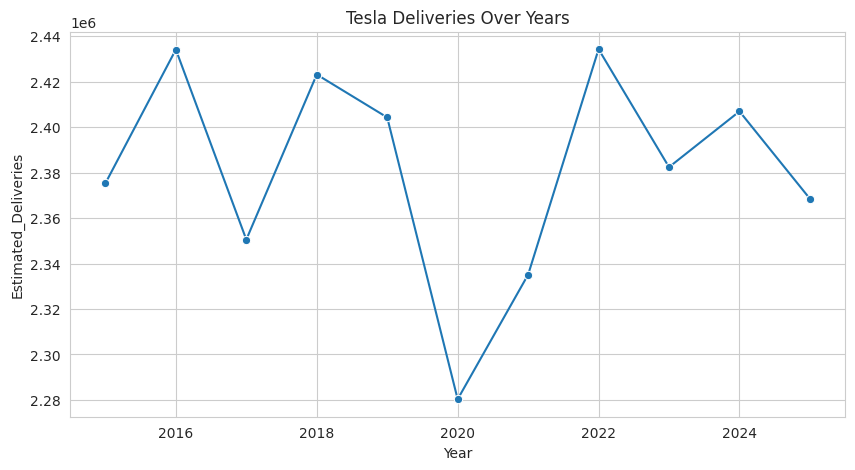

In [19]:
yearly = df.groupby("Year")["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly,
    x="Year",
    y="Estimated_Deliveries",
    marker="o"
)

plt.title("Tesla Deliveries Over Years")

plt.show()

##**Data Processing**

##encode categorical features

In [20]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_ml["Region"] = le_region.fit_transform(df_ml["Region"])
df_ml["Model"] = le_model.fit_transform(df_ml["Model"])
df_ml["Source_Type"] = le_source.fit_transform(df_ml["Source_Type"])

##feature engineering

In [21]:
df_ml["Delivery_Gap"] = (
    df_ml["Production_Units"] - df_ml["Estimated_Deliveries"]
)

df_ml["Delivery_Efficiency"] = (
    df_ml["Estimated_Deliveries"] /
    df_ml["Production_Units"]
)

df_ml["Price_per_kWh"] = (
    df_ml["Avg_Price_USD"] /
    df_ml["Battery_Capacity_kWh"]
)

In [22]:
df_ml.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Gap,Delivery_Efficiency,Price_per_kWh
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,276,0.984600,773.952250
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,367,0.911864,829.408667
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,778,0.915334,1437.650244
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,756,0.896594,744.124250
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,1163,0.914087,957.056500


##train test split

In [23]:
X = df_ml.drop("Estimated_Deliveries", axis=1)
y = df_ml["Estimated_Deliveries"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 14)
(528, 14)


##feature scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##linear regression model

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2  :", r2_score(y_test, pred_lr))

Linear Regression Results
-------------------------
MAE : 2.303019727784858e-12
RMSE: 2.9569176078956652e-12
R2  : 1.0


##random forest

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [30]:
print("Random Forest Results")
print("---------------------")
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2  :", r2_score(y_test, pred_rf))

Random Forest Results
---------------------
MAE : 66.32958333333333
RMSE: 108.22952755707325
R2  : 0.9992141819257708


redefine X and Y

In [31]:
# Target
y = df_ml["Estimated_Deliveries"]

# Features (remove leakage features)
X = df_ml.drop(
    columns=[
        "Estimated_Deliveries",
        "Delivery_Gap",
        "Delivery_Efficiency"
    ]
)

##train-test split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##feature scaling

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
#LR
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2  :", r2_score(y_test, pred_lr))

Linear Regression Results
-------------------------
MAE : 310.0452260587412
RMSE: 383.66616597449934
R2  : 0.9901249911720438


In [36]:
#RM
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [37]:
print("Random Forest Results")
print("---------------------")
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2  :", r2_score(y_test, pred_rf))

Random Forest Results
---------------------
MAE : 325.13015151515157
RMSE: 411.0863015273181
R2  : 0.9886630430200831


##Hyperparameter tuning

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [39]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation R²:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross Validation R²:
0.9886175963445977


#time series forecasting


In [40]:
from statsmodels.tsa.arima.model import ARIMA

# Aggregate monthly deliveries
ts = (
    df.groupby(["Year", "Month"])["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

# Create a proper date column
ts["Date"] = pd.to_datetime(
    ts["Year"].astype(str) + "-" + ts["Month"].astype(str)
)

ts = ts.sort_values("Date")
ts.set_index("Date", inplace=True)

ts = ts["Estimated_Deliveries"]

ts.head()

,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


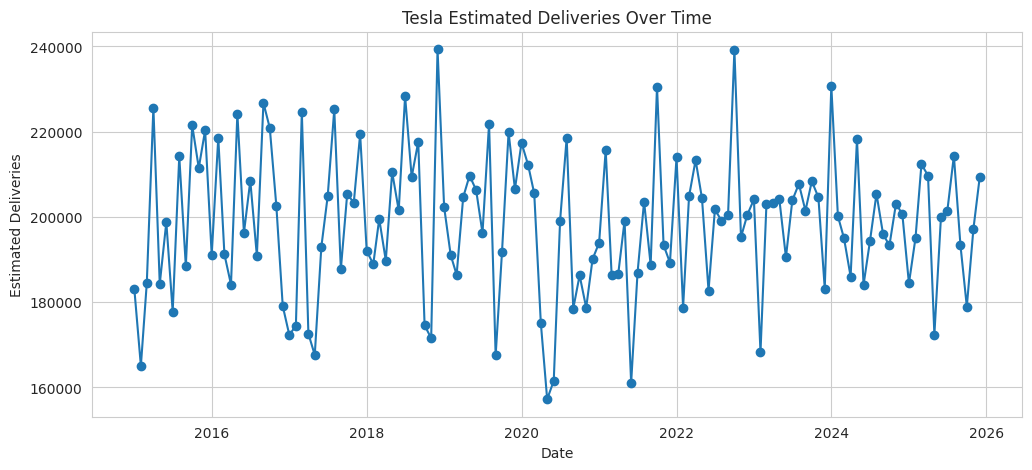

In [41]:
plt.figure(figsize=(12,5))

plt.plot(ts, marker="o")

plt.title("Tesla Estimated Deliveries Over Time")

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

In [42]:
model = ARIMA(ts, order=(2,1,2))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(2, 1, 2)   Log Likelihood               -1490.869
Date:                  Sun, 28 Jun 2026   AIC                           2991.738
Time:                          12:23:41   BIC                           3006.114
Sample:                      01-01-2015   HQIC                          2997.579
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2137      1.068      0.200      0.841      -1.879       2.307
ar.L2          0.0365      0.193      0.189      0.850      -0.342       0.415
ma.L1         -0.7846      1.082    

In [43]:
forecast = model_fit.forecast(steps=12)

forecast

,predicted_mean
2026-01-01,201434.637490
2026-02-01,200328.856466
2026-03-01,199801.924404
2026-04-01,199648.939971
2026-05-01,199597.002306
2026-06-01,199580.316099
2026-07-01,199574.853416
2026-08-01,199573.076638
2026-09-01,199572.497436
2026-10-01,199572.308771


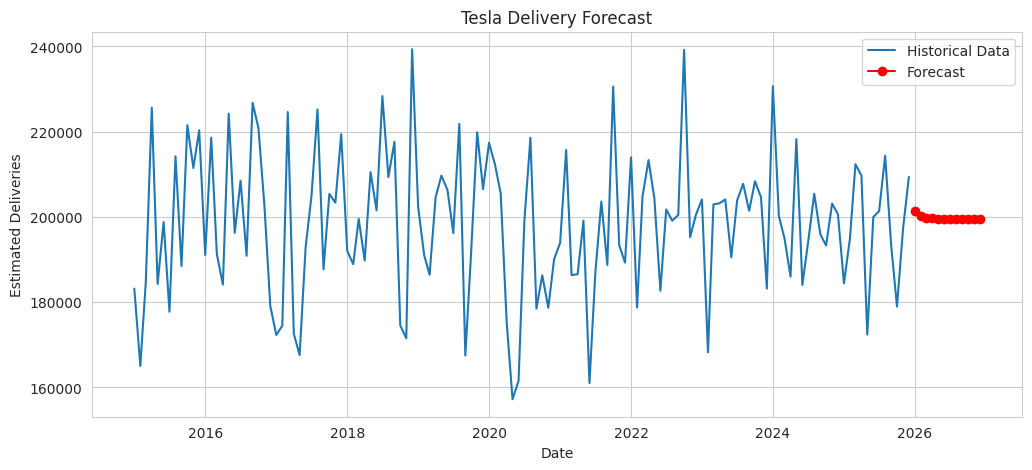

In [44]:
plt.figure(figsize=(12,5))

plt.plot(ts, label="Historical Data")

forecast_index = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

plt.plot(
    forecast_index,
    forecast,
    color="red",
    marker="o",
    label="Forecast"
)

plt.title("Tesla Delivery Forecast")

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

# Conclusion

In this project, an end-to-end Machine Learning pipeline was developed using Tesla delivery and production data. The workflow included data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning, and time-series forecasting.

Among the regression models evaluated, Linear Regression achieved the highest predictive performance with an R² score of approximately 0.99. Time-series forecasting using the ARIMA model provided projected delivery trends for future months, demonstrating the application of statistical forecasting techniques.

This project highlights the complete lifecycle of a machine learning solution, from raw data analysis to predictive modeling and business insights.